# Adversarial Simulator Parameter Calibration

This notebook trains a generator to drive the simulator so a discriminator struggles to separate real vs simulated BEC images.

The simulation and training path below is torch-native and differentiable, so generator optimization uses direct backpropagation through the renderer.

In [1]:
# Core imports
import ast
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
# Load selected function definitions directly from new_images.ipynb
def _read_ipynb_cells(notebook_path: Path):
    with notebook_path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    return data.get('cells', [])

def _extract_selected_code(cells, function_names, assignment_names=('IMAGE_HEIGHT', 'IMAGE_WIDTH')):
    function_names = set(function_names)
    assignment_names = set(assignment_names)
    snippets = []

    for cell in cells:
        if cell.get('cell_type') != 'code':
            continue

        src = ''.join(cell.get('source', []))
        if not src.strip():
            continue

        try:
            tree = ast.parse(src)
        except SyntaxError:
            continue

        lines = src.splitlines()
        for node in tree.body:
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)) and node.name in function_names:
                snippet = '\n'.join(lines[node.lineno - 1: node.end_lineno])
                snippets.append(snippet)
            elif isinstance(node, ast.Assign):
                target_names = []
                for t in node.targets:
                    if isinstance(t, ast.Name):
                        target_names.append(t.id)
                if any(name in assignment_names for name in target_names):
                    snippet = '\n'.join(lines[node.lineno - 1: node.end_lineno])
                    snippets.append(snippet)

    return '\n\n'.join(snippets)

def import_functions_from_notebook(notebook_path: Path, function_names):
    cells = _read_ipynb_cells(notebook_path)
    code = _extract_selected_code(cells, function_names)

    namespace = {
        'np': np,
        'pd': pd,
        'random': random,
        'Path': Path,
        'tqdm': tqdm,
        'curve_fit': curve_fit,
        'gaussian_filter': gaussian_filter,
    }

    exec(code, namespace)
    return namespace

In [3]:
# Import required simulator functions from new_images.ipynb
NB_PATH = Path('./new_images.ipynb').resolve()
if not NB_PATH.exists():
    raise FileNotFoundError(f'Cannot find notebook: {NB_PATH}')

required_functions = [
    'load_bec_dataset',
    'thomas_fermi_2d',
    'fit_thomas_fermi_image',
    'sample_thomas_fermi_cloud',
    'add_dark_soliton_excitation',
    'apply_fresnel_diffraction',
    'add_shot_noise',
    'add_read_noise',
    'add_shift',
    'add_exposure_variation',
    'add_gaussian_blur',
    'simulate_bec_image',
]

ns = import_functions_from_notebook(NB_PATH, required_functions)

missing = [name for name in required_functions if name not in ns]
if missing:
    raise RuntimeError(f'Missing imported functions: {missing}')

globals().update({name: ns[name] for name in required_functions})
IMAGE_HEIGHT = int(ns.get('IMAGE_HEIGHT', 132))
IMAGE_WIDTH = int(ns.get('IMAGE_WIDTH', 164))

print('Imported functions from:', NB_PATH)
print('Image shape:', (IMAGE_HEIGHT, IMAGE_WIDTH))

Imported functions from: C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\new_images.ipynb
Image shape: (132, 164)


In [4]:
# Load real dataset
DATA_DIR = Path('../../data')
DATA_FILES_DIR = DATA_DIR / 'data_files' / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_info' / 'data_roster.csv'

print('Data files dir exists:', DATA_FILES_DIR.exists())
print('Labels file exists:', LABELS_FILE.exists())

labels_df = pd.read_csv(LABELS_FILE, index_col=0)
images, labels, positions, file_paths = load_bec_dataset(
    DATA_FILES_DIR,
    labels_df,
    max_samples=None,
    shuffle_seed=SEED,
)

images = np.clip(images.astype(np.float32), 0.0, 1.0)
use_mask = np.isin(labels, [0, 1, 2])
real_images = images[use_mask]
real_labels = labels[use_mask]

print('Filtered real images:', real_images.shape)
print('Label distribution:', {int(k): int(v) for k, v in zip(*np.unique(real_labels, return_counts=True))})

Data files dir exists: True
Labels file exists: True
Discovered class folders: ['class-0', 'class-1', 'class-2', 'class-8', 'class-9']
Found 16478 .npy files
Loading 16478 samples...


100%|██████████| 16478/16478 [04:55<00:00, 55.72it/s]


Loaded 16478 images
Image shape: (16478, 132, 164, 1)
Value range: [-0.479, 3.492]
Label distribution: [ 1130  3212  1036     0     0     0     0     0   879 10221]
Filtered real images: (5378, 132, 164, 1)
Label distribution: {0: 1130, 1: 3212, 2: 1036}


In [5]:
# Build a bank of fitted TF anchor parameters for simulation seeds
anchor_candidates = np.where(np.isin(real_labels, [0, 1]))[0]
rng = np.random.default_rng(SEED)
rng.shuffle(anchor_candidates)
anchor_candidates = anchor_candidates[:180]

anchor_params_bank = []
for idx in tqdm(anchor_candidates, desc='Fitting TF anchors'):
    try:
        p, _, _ = fit_thomas_fermi_image(real_images[idx].squeeze())
        anchor_params_bank.append(p.astype(np.float32))
    except Exception:
        continue

if len(anchor_params_bank) < 20:
    raise RuntimeError('Too few anchor parameter fits succeeded; increase candidates or inspect fit function.')

anchor_params_bank = np.stack(anchor_params_bank, axis=0)
anchor_params_bank_t = torch.from_numpy(anchor_params_bank).to(device)
print('Anchor bank size (numpy):', anchor_params_bank.shape)
print('Anchor bank size (torch):', tuple(anchor_params_bank_t.shape))

Fitting TF anchors:   0%|          | 0/180 [00:00<?, ?it/s]

Fitting TF anchors: 100%|██████████| 180/180 [00:18<00:00,  9.53it/s]


Anchor bank size (numpy): (180, 7)
Anchor bank size (torch): (180, 7)


In [6]:
# Train/validation split for discriminator evaluation
idx = torch.randperm(len(real_images), generator=torch.Generator().manual_seed(SEED))
split = int(0.9 * len(idx))
train_idx = idx[:split].cpu().numpy()
val_idx = idx[split:].cpu().numpy()

real_train = torch.from_numpy(real_images[train_idx]).float()
real_val = torch.from_numpy(real_images[val_idx]).float()

print('Train real:', tuple(real_train.shape), 'Val real:', tuple(real_val.shape))

Train real: (4840, 132, 164, 1) Val real: (538, 132, 164, 1)


In [36]:
# Models: discriminator and differentiable generator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

class ParamGenerator(nn.Module):
    def __init__(self, z_dim=64, n_out=23):
        super().__init__()
        self.z_dim = z_dim
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, n_out),
        )

    def forward(self, z):
        return self.net(z)

In [ ]:
# Unified simulator API + differentiable torch renderer and fake-batch synthesis
SIM_PARAM_DEFAULTS = {
    'add_soliton': True,
    'num_solitons': 1,
    'base_soliton_angle': 0.0,
    'angle_jitter_deg': 0.0,
    'shot_photons': 4,
    'read_noise_std': 0.035,
    'gaussian_sigma': 0.8,
    'pixel_size': 5.6e-6,
    'propagation_distance': 2.0e-3,
    'phase_scale': 0.75,
    'blend': 0.75,
    'base_gain_low': 0.9,
    'base_gain_high': 1.12,
    'overexposure_prob': 0.2,
    'overexposure_gain_low': 1.12,
    'overexposure_gain_high': 1.42,
    'shift_i': 0.0,
    'shift_j': 0.0,
    'shift_prob': 0.25,
    'soliton_depth': 0.86,
    'soliton_width_px': 2.0,
    'fringe_gain': 1.2,
    'fringe_period_px': 12.0,
    'fringe_decay_px': 7.0,
    'fringe_phase': 0.0,
    'side_antisym': 0.0,
    'side_antisym_scale_px': 9.0,
    'diagonal_antisym': 0.0,
    'diagonal_antisym_scale_px': 15.0,
    'diagonal_angle_rad': 0.0,
    'y_fade_px': 30.0,
    'y_fade_power': 1.9,
}

def build_simulate_image_kwargs(**overrides):
    kwargs = dict(SIM_PARAM_DEFAULTS)
    kwargs.update(overrides)
    return kwargs

def _to_float_tensor(v, device, dtype=torch.float32):
    return torch.tensor([float(v)], device=device, dtype=dtype)

def _base_angle_to_deg(base_angle_value):
    # Treat small magnitudes as radians (exported records), otherwise assume degrees.
    a = float(base_angle_value)
    if abs(a) <= (2.0 * np.pi + 1e-6):
        return float(np.rad2deg(a))
    return a

def _cfg_to_torch_params(cfg, device, dtype=torch.float32):
    n_sol = int(max(0, min(2, int(cfg.get('num_solitons', 1)))))
    return {
        'base_angle_deg': _to_float_tensor(_base_angle_to_deg(cfg.get('base_soliton_angle', 0.0)), device, dtype),
        'angle_jitter_deg': _to_float_tensor(cfg['angle_jitter_deg'], device, dtype),
        'shot_photons': _to_float_tensor(cfg['shot_photons'], device, dtype),
        'read_noise_std': _to_float_tensor(cfg['read_noise_std'], device, dtype),
        'gaussian_sigma': _to_float_tensor(cfg['gaussian_sigma'], device, dtype),
        'pixel_size': _to_float_tensor(cfg['pixel_size'], device, dtype),
        'propagation_distance': _to_float_tensor(cfg['propagation_distance'], device, dtype),
        'phase_scale': _to_float_tensor(cfg['phase_scale'], device, dtype),
        'blend': _to_float_tensor(cfg['blend'], device, dtype),
        'base_gain_low': _to_float_tensor(cfg['base_gain_low'], device, dtype),
        'base_gain_high': _to_float_tensor(cfg['base_gain_high'], device, dtype),
        'overexposure_prob': _to_float_tensor(cfg['overexposure_prob'], device, dtype),
        'overexposure_gain_low': _to_float_tensor(cfg['overexposure_gain_low'], device, dtype),
        'overexposure_gain_high': _to_float_tensor(cfg['overexposure_gain_high'], device, dtype),
        'shift_prob': _to_float_tensor(cfg['shift_prob'], device, dtype),
        'shift_i': _to_float_tensor(cfg['shift_i'], device, dtype),
        'shift_j': _to_float_tensor(cfg['shift_j'], device, dtype),
        'n_solitons_soft': _to_float_tensor(n_sol, device, dtype),
        'soliton_depth': _to_float_tensor(cfg['soliton_depth'], device, dtype),
        'soliton_width_px': _to_float_tensor(cfg['soliton_width_px'], device, dtype),
        'fringe_gain': _to_float_tensor(cfg['fringe_gain'], device, dtype),
        'fringe_period_px': _to_float_tensor(cfg['fringe_period_px'], device, dtype),
        'fringe_decay_px': _to_float_tensor(cfg['fringe_decay_px'], device, dtype),
        'fringe_phase': _to_float_tensor(cfg['fringe_phase'], device, dtype),
        'side_antisym': _to_float_tensor(cfg['side_antisym'], device, dtype),
        'side_antisym_scale_px': _to_float_tensor(cfg['side_antisym_scale_px'], device, dtype),
        'diagonal_antisym': _to_float_tensor(cfg['diagonal_antisym'], device, dtype),
        'diagonal_antisym_scale_px': _to_float_tensor(cfg['diagonal_antisym_scale_px'], device, dtype),
        'diagonal_angle_rad': _to_float_tensor(cfg['diagonal_angle_rad'], device, dtype),
        'y_fade_px': _to_float_tensor(cfg['y_fade_px'], device, dtype),
        'y_fade_power': _to_float_tensor(cfg['y_fade_power'], device, dtype),
    }

def simulate_image(tf_params, rng=None, soliton_specs=None, **kwargs):
    """Torch-native differentiable simulator that mirrors the numpy pipeline semantics."""
    if rng is None:
        rng = np.random.default_rng()

    cfg = build_simulate_image_kwargs(**kwargs)

    anchor = np.asarray(tf_params, dtype=np.float32)
    if anchor.ndim != 1:
        anchor = anchor.reshape(-1)
    anchor_t = torch.from_numpy(anchor[None, :]).to(device=device, dtype=torch.float32)
    params_t = _cfg_to_torch_params(cfg, device=device, dtype=torch.float32)

    # Sync torch stochastic draws with provided numpy RNG for replayability.
    torch_seed = int(rng.integers(0, 2**31 - 1))
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(torch_seed)
        img_t = differentiable_bec_render(anchor_t, params_t)

    img = img_t.squeeze(0).squeeze(0).detach().cpu().numpy()
    return np.clip(img, 0.0, 1.0), cfg

def squash_range(x, low, high):
    s = torch.sigmoid(x)
    return low + (high - low) * s

def make_coordinate_grid(height, width, device):
    yy = torch.linspace(0.0, float(height - 1), height, device=device)
    xx = torch.linspace(0.0, float(width - 1), width, device=device)
    y_grid, x_grid = torch.meshgrid(yy, xx, indexing='ij')
    return x_grid[None, :, :], y_grid[None, :, :]

def smooth_floor(x, beta=8.0):
    return F.softplus(beta * x) / beta

def smooth_clip(x, low=0.0, high=1.0, softness=5.0):
    span = max(high - low, 1e-8)
    z = (x - low) / span
    return low + span * torch.sigmoid(softness * (z - 0.5))

X_GRID, Y_GRID = make_coordinate_grid(IMAGE_HEIGHT, IMAGE_WIDTH, device)
FIXED_EXCITATION_PROBS = (0.20, 0.60, 0.20)

# Toggle trainable controls here. Re-run this cell after changing preset/toggles.
TRAINABLE_PRESETS = {
    'all_current': {
        'angle_jitter_deg': True,
        'shot_photons': True,
        'gaussian_sigma': False,
        'propagation_distance': True,
        'phase_scale': True,
        'blend': True,
        'base_gain_low': True,
        'base_gain_high': True,
        'overexposure_prob': True,
        'overexposure_gain_low': False,
        'overexposure_gain_high': False,
        'shift_prob': True,
        'shift_i': True,
        'shift_j': True,
        'soliton_depth': True,
        'soliton_width_px': True,
        'fringe_gain': True,
        'fringe_period_px': True,
        'fringe_decay_px': True,
        'fringe_phase': True,
        'side_antisym': True,
        'diagonal_antisym': True,
        'y_fade_px': True,
    },
    'soliton_only': {
        'angle_jitter_deg': True,
        'shot_photons': False,
        'gaussian_sigma': False,
        'propagation_distance': False,
        'phase_scale': False,
        'blend': False,
        'base_gain_low': True,
        'base_gain_high': True,
        'overexposure_prob': False,
        'overexposure_gain_low': False,
        'overexposure_gain_high': False,
        'shift_prob': False,
        'shift_i': False,
        'shift_j': False,
        'soliton_depth': True,
        'soliton_width_px': True,
        'fringe_gain': True,
        'fringe_period_px': True,
        'fringe_decay_px': True,
        'fringe_phase': True,
        'side_antisym': True,
        'diagonal_antisym': True,
        'y_fade_px': True,
    },
    'noise_only': {
        'angle_jitter_deg': False,
        'shot_photons': True,
        'gaussian_sigma': False,
        'propagation_distance': False,
        'phase_scale': False,
        'blend': False,
        'base_gain_low': False,
        'base_gain_high': False,
        'overexposure_prob': False,
        'overexposure_gain_low': False,
        'overexposure_gain_high': False,
        'shift_prob': True,
        'shift_i': True,
        'shift_j': True,
        'soliton_depth': False,
        'soliton_width_px': False,
        'fringe_gain': False,
        'fringe_period_px': False,
        'fringe_decay_px': False,
        'fringe_phase': False,
        'side_antisym': False,
        'diagonal_antisym': False,
        'y_fade_px': False,
    },
}
RAW_PARAM_ORDER = [
    'angle_jitter_deg',
    'shot_photons',
    'gaussian_sigma',
    'propagation_distance',
    'phase_scale',
    'blend',
    'base_gain_low',
    'base_gain_high',
    'overexposure_prob',
    'overexposure_gain_low',
    'overexposure_gain_high',
    'shift_prob',
    'shift_i',
    'shift_j',
    'soliton_depth',
    'soliton_width_px',
    'fringe_gain',
    'fringe_period_px',
    'fringe_decay_px',
    'fringe_phase',
    'side_antisym',
    'diagonal_antisym',
    'y_fade_px',
]
RAW_PARAM_INDEX = {k: i for i, k in enumerate(RAW_PARAM_ORDER)}
N_GENERATOR_OUTPUTS = len(RAW_PARAM_ORDER)

ACTIVE_TRAINABLE_PRESET = 'noise_only'
TRAINABLE_PARAM_TOGGLES = dict(TRAINABLE_PRESETS[ACTIVE_TRAINABLE_PRESET])
N_TRAINABLE_PARAMS = int(sum(1 for v in TRAINABLE_PARAM_TOGGLES.values() if v))
print(f"Active preset: {ACTIVE_TRAINABLE_PRESET} | trainable params: {N_TRAINABLE_PARAMS}/{N_GENERATOR_OUTPUTS}")

def set_trainable_preset(preset_name, announce=True):
    global ACTIVE_TRAINABLE_PRESET, TRAINABLE_PARAM_TOGGLES, N_TRAINABLE_PARAMS
    if preset_name not in TRAINABLE_PRESETS:
        raise KeyError(f'Unknown preset: {preset_name}')
    ACTIVE_TRAINABLE_PRESET = preset_name
    TRAINABLE_PARAM_TOGGLES = dict(TRAINABLE_PRESETS[preset_name])
    N_TRAINABLE_PARAMS = int(sum(1 for v in TRAINABLE_PARAM_TOGGLES.values() if v))
    if announce:
        print(f"Active preset: {ACTIVE_TRAINABLE_PRESET} | trainable params: {N_TRAINABLE_PARAMS}/{N_GENERATOR_OUTPUTS}")

def _active_param_count():
    return int(sum(1 for v in TRAINABLE_PARAM_TOGGLES.values() if v))

def sample_fixed_excitation_counts(batch_size, device):
    probs = torch.tensor(FIXED_EXCITATION_PROBS, device=device, dtype=torch.float32)
    counts = torch.multinomial(probs, num_samples=batch_size, replacement=True)
    return counts

def _const_from_raw(raw, value):
    if raw.shape[1] > 0:
        return torch.full_like(raw[:, 0], float(value))
    return torch.full((raw.shape[0],), float(value), device=raw.device, dtype=raw.dtype)

def _decode_param(raw, key, low, high, fixed):
    idx = RAW_PARAM_INDEX[key]
    if TRAINABLE_PARAM_TOGGLES.get(key, False):
        return squash_range(raw[:, idx], low, high)
    return _const_from_raw(raw, fixed)

def decode_generator_output(raw):
    if raw.shape[1] != N_GENERATOR_OUTPUTS:
        raise ValueError(f'Expected generator output dim {N_GENERATOR_OUTPUTS}, got {raw.shape[1]}')

    angle_jitter_deg = _decode_param(raw, 'angle_jitter_deg', -1.5, 1.5, 0.0)
    shot_photons = _decode_param(raw, 'shot_photons', 1.0, 12.0, 4.0)
    gaussian_sigma = _decode_param(raw, 'gaussian_sigma', 0.0, 2.0, 0.8)
    propagation_distance = _decode_param(raw, 'propagation_distance', 0.1e-3, 10.0e-3, 2.0e-3)
    phase_scale = _decode_param(raw, 'phase_scale', 0.1, 1.5, 0.75)
    blend = _decode_param(raw, 'blend', 0.1, 1.5, 0.75)
    base_gain_low = _decode_param(raw, 'base_gain_low', 0.5, 1.5, 0.9)
    base_gain_high = _decode_param(raw, 'base_gain_high', 0.5, 1.5, 1.12)
    overexposure_prob = _decode_param(raw, 'overexposure_prob', 0.0, 1.0, 0.2)
    overexposure_gain_low = _decode_param(raw, 'overexposure_gain_low', 0.5, 1.50, 1.12)
    overexposure_gain_high = _decode_param(raw, 'overexposure_gain_high', 0.5, 1.50, 1.42)
    shift_prob = _decode_param(raw, 'shift_prob', 0.0, 1.0, 0.25)
    shift_i = _decode_param(raw, 'shift_i', -5.0, 6.0, 0.0)
    shift_j = _decode_param(raw, 'shift_j', -5.0, 5.0, 0.0)
    soliton_depth = _decode_param(raw, 'soliton_depth', 0.1, 1.0, 0.86)
    soliton_width_px = _decode_param(raw, 'soliton_width_px', 0.1, 6.0, 2.0)
    fringe_gain = _decode_param(raw, 'fringe_gain', 0.1, 2.0, 1.2)
    fringe_period_px = _decode_param(raw, 'fringe_period_px', 5.0, 20.0, 12.0)
    fringe_decay_px = _decode_param(raw, 'fringe_decay_px', 5.0, 20.0, 7.0)
    fringe_phase = _decode_param(raw, 'fringe_phase', -0.5, 0.5, 0.0)
    side_antisym = _decode_param(raw, 'side_antisym', -0.99, 0.99, 0.0)
    diagonal_antisym = _decode_param(raw, 'diagonal_antisym', -0.99, 0.99, 0.0)
    y_fade_px = _decode_param(raw, 'y_fade_px', 5.0, 70.0, 30.0)

    return {
        'base_angle_deg': _const_from_raw(raw, 0.0),
        'angle_jitter_deg': angle_jitter_deg,
        'shot_photons': shot_photons,
        'read_noise_std': _const_from_raw(raw, 0.035),
        'gaussian_sigma': gaussian_sigma,
        'pixel_size': _const_from_raw(raw, 5.6e-6),
        'propagation_distance': propagation_distance,
        'phase_scale': phase_scale,
        'blend': blend,
        'base_gain_low': base_gain_low,
        'base_gain_high': base_gain_high,
        'overexposure_prob': overexposure_prob,
        'overexposure_gain_low': overexposure_gain_low,
        'overexposure_gain_high': overexposure_gain_high,
        'shift_prob': shift_prob,
        'shift_i': shift_i,
        'shift_j': shift_j,
        'n_solitons_soft': _const_from_raw(raw, 0.0),
        'soliton_depth': soliton_depth,
        'soliton_width_px': soliton_width_px,
        'fringe_gain': fringe_gain,
        'fringe_period_px': fringe_period_px,
        'fringe_decay_px': fringe_decay_px,
        'fringe_phase': fringe_phase,
        'side_antisym': side_antisym,
        'side_antisym_scale_px': _const_from_raw(raw, 9.0),
        'diagonal_antisym': diagonal_antisym,
        'diagonal_antisym_scale_px': _const_from_raw(raw, 15.0),
        'diagonal_angle_rad': _const_from_raw(raw, 0.0),
        'y_fade_px': y_fade_px,
        'y_fade_power': _const_from_raw(raw, 1.9),
    }

def _sample_tf_params_torch(anchor_batch):
    # Matches sample_thomas_fermi_cloud in new_images.ipynb.
    bsz = anchor_batch.shape[0]
    n0 = torch.abs(anchor_batch[:, 0]) + 1e-6
    i0 = anchor_batch[:, 1] if anchor_batch.shape[1] > 1 else torch.full_like(n0, (IMAGE_HEIGHT - 1) / 2.0)
    j0 = anchor_batch[:, 2] if anchor_batch.shape[1] > 2 else torch.full_like(n0, (IMAGE_WIDTH - 1) / 2.0)
    Ri = torch.abs(anchor_batch[:, 3]) if anchor_batch.shape[1] > 3 else torch.full_like(n0, IMAGE_HEIGHT / 3.0)
    Rj = torch.abs(anchor_batch[:, 4]) if anchor_batch.shape[1] > 4 else torch.full_like(n0, IMAGE_WIDTH / 3.0)
    theta = anchor_batch[:, 5] if anchor_batch.shape[1] > 5 else torch.zeros_like(n0)
    delta_n = anchor_batch[:, 6] if anchor_batch.shape[1] > 6 else torch.zeros_like(n0)

    u = torch.rand(bsz, 7, device=anchor_batch.device, dtype=anchor_batch.dtype)
    n0s = n0 * (0.9 + 0.2 * u[:, 0])
    i0s = i0 + (-3.0 + 6.0 * u[:, 1])
    j0s = j0 + (-3.0 + 6.0 * u[:, 2])
    Ris = torch.clamp(Ri * (0.9 + 0.2 * u[:, 3]), min=1.0)
    Rjs = torch.clamp(Rj * (0.9 + 0.2 * u[:, 4]), min=1.0)
    thetas = theta + (-0.12 + 0.24 * u[:, 5])
    delta_ns = delta_n + (-0.01 + 0.02 * u[:, 6])
    return n0s, i0s, j0s, Ris, Rjs, thetas, delta_ns

def _tf_cloud_torch(n0, i0, j0, Ri, Rj, theta, delta_n, xg, yg):
    di = yg - i0[:, None, None]
    dj = xg - j0[:, None, None]
    ct = torch.cos(theta)[:, None, None]
    st = torch.sin(theta)[:, None, None]
    i_theta = ct * di + st * dj
    j_theta = -st * di + ct * dj
    inside = 1.0 - (i_theta / Ri[:, None, None]) ** 2 - (j_theta / Rj[:, None, None]) ** 2
    tf_core = torch.clamp(inside, min=0.0).pow(1.5)
    cloud = n0[:, None, None] * tf_core + delta_n[:, None, None]
    return torch.clamp(cloud, 0.0, 1.0)

def _add_dark_soliton_excitation_torch(image, i0, j0, angle_rad, depth, width_px, fringe_gain, fringe_period_px, fringe_decay_px, fringe_phase, side_antisym, side_antisym_scale_px, diagonal_antisym, diagonal_antisym_scale_px, diagonal_angle_rad, y_fade_px, y_fade_power, xg, yg):
    d = (xg - j0[:, None, None]) * torch.cos(angle_rad)[:, None, None] - (yg - i0[:, None, None]) * torch.sin(angle_rad)[:, None, None]
    t = (xg - j0[:, None, None]) * torch.sin(angle_rad)[:, None, None] + (yg - i0[:, None, None]) * torch.cos(angle_rad)[:, None, None]

    t_scale = torch.clamp(y_fade_px[:, None, None], min=1e-3)
    fade_pow = torch.clamp(y_fade_power[:, None, None], min=1e-3)
    y_fade = torch.exp(-0.5 * (torch.abs(t) / t_scale).pow(fade_pow))
    width_eff = torch.clamp(width_px[:, None, None], min=1e-3)
    notch = torch.exp(-(d ** 2) / (2.0 * width_eff ** 2)) * y_fade
    depletion = image * (1.0 - depth[:, None, None] * notch)

    period = torch.clamp(fringe_period_px[:, None, None], min=1e-3)
    decay = torch.clamp(fringe_decay_px[:, None, None], min=1e-3)
    envelope = torch.exp(-(d ** 2) / (2.0 * decay ** 2)) * y_fade
    ringing = -torch.cos((2.0 * np.pi * d / period) + fringe_phase[:, None, None]) * envelope

    side_scale = torch.clamp(side_antisym_scale_px[:, None, None], min=1e-3)
    side_field = torch.tanh(d / side_scale)
    ii = yg - i0[:, None, None]
    jj = xg - j0[:, None, None]
    cdr = torch.cos(diagonal_angle_rad)[:, None, None]
    sdr = torch.sin(diagonal_angle_rad)[:, None, None]
    x_diag = jj * cdr - ii * sdr
    y_diag = jj * sdr + ii * cdr
    diag_scale = torch.clamp(diagonal_antisym_scale_px[:, None, None], min=1e-3)
    diag_field = torch.tanh((x_diag * y_diag) / (diag_scale ** 2))

    amplitude_mod = 1.0 + side_antisym[:, None, None] * side_field + diagonal_antisym[:, None, None] * diag_field
    amplitude_mod = torch.clamp(amplitude_mod, 0.0, 2.5)
    ringing = torch.clamp(ringing * amplitude_mod, -1.0, 1.0)

    return depletion + fringe_gain[:, None, None] * ringing * image

def _apply_fresnel_diffraction_torch(image, pixel_size, propagation_distance, phase_scale, blend, na=0.22, wavelength=780e-9):
    bsz, h, w = image.shape
    img = torch.clamp(image, 0.0, 1.0)

    out = []
    for i in range(bsz):
        px = float(torch.clamp(pixel_size[i], min=1e-12).item())
        fy = torch.fft.fftfreq(h, d=px, device=image.device)
        fx = torch.fft.fftfreq(w, d=px, device=image.device)
        FY, FX = torch.meshgrid(fy, fx, indexing='ij')

        amplitude = torch.sqrt(torch.clamp(img[i], min=0.0) + 1e-8)
        phase = phase_scale[i] * img[i]
        field0 = amplitude * torch.exp(1j * phase)

        H = torch.exp(-1j * np.pi * wavelength * propagation_distance[i] * (FX ** 2 + FY ** 2))
        if na is not None and na > 0:
            f_cut = na / wavelength
            H = H * ((FX ** 2 + FY ** 2) <= (f_cut ** 2))

        field_z = torch.fft.ifft2(torch.fft.fft2(field0) * H)
        intensity_z = torch.abs(field_z) ** 2
        intensity_z = intensity_z - intensity_z.min()
        max_v = intensity_z.max()
        if float(max_v.item()) > 0.0:
            intensity_z = intensity_z / max_v

        out_i = (1.0 - blend[i]) * img[i] + blend[i] * intensity_z
        out.append(out_i)

    return torch.stack(out, dim=0)

def _apply_integer_roll_blend_torch(image, shift_i, shift_j, alpha):
    bsz = image.shape[0]
    out = []
    for i in range(bsz):
        si = int(torch.round(shift_i[i]).item())
        sj = int(torch.round(shift_j[i]).item())
        shifted = torch.roll(image[i], shifts=(si, sj), dims=(0, 1))
        out.append((1.0 - alpha[i]) * image[i] + alpha[i] * shifted)
    return torch.stack(out, dim=0)

def _gaussian_kernel1d(sigma, radius, device, dtype):
    x = torch.arange(-radius, radius + 1, device=device, dtype=dtype)
    k = torch.exp(-(x ** 2) / (2.0 * sigma ** 2))
    return k / torch.clamp(k.sum(), min=1e-8)

def _gaussian_blur_torch(image, sigma):
    bsz, h, w = image.shape
    out = []
    for i in range(bsz):
        s = float(torch.clamp(sigma[i], min=0.0).item())
        if s <= 0.0:
            out.append(image[i])
            continue
        radius = max(1, int(np.ceil(3.0 * s)))
        k1 = _gaussian_kernel1d(max(s, 1e-3), radius, image.device, image.dtype)
        k2 = torch.outer(k1, k1)
        k2 = k2[None, None, :, :]
        pad = radius
        x = F.pad(image[i][None, None, :, :], (pad, pad, pad, pad), mode='reflect')
        y = F.conv2d(x, k2)
        out.append(y[0, 0])
    return torch.stack(out, dim=0)

def _shot_noise_straight_through(image, photons_per_pixel):
    photons = torch.clamp(photons_per_pixel[:, None, None], min=2.0)
    expected = torch.clamp(image, 0.0, 1.0) * photons
    poisson_counts = torch.poisson(expected)
    noisy_forward = poisson_counts / photons
    # Forward matches Poisson exactly; backward uses identity surrogate.
    return image + (noisy_forward - image).detach()

def differentiable_bec_render(anchor_batch, params):
    bsz = anchor_batch.shape[0]
    xg = X_GRID.expand(bsz, -1, -1)
    yg = Y_GRID.expand(bsz, -1, -1)

    n0, i0, j0, Ri, Rj, theta_tf, delta_n = _sample_tf_params_torch(anchor_batch)
    density = _tf_cloud_torch(n0, i0, j0, Ri, Rj, theta_tf, delta_n, xg, yg)

    n_soft = torch.clamp(params['n_solitons_soft'], 0.0, 2.0)
    add_1 = torch.sigmoid((n_soft - 0.5) * 36.0)
    add_2 = torch.sigmoid((n_soft - 1.5) * 36.0)

    angle_rad = torch.deg2rad(params['base_angle_deg'] + params['angle_jitter_deg'])
    u = torch.rand(bsz, 4, device=anchor_batch.device, dtype=anchor_batch.dtype)
    si1 = i0 + (-0.4 + 0.8 * u[:, 0]) * Ri
    sj1 = j0 + (-0.4 + 0.8 * u[:, 1]) * Rj
    si2 = i0 + (-0.4 + 0.8 * u[:, 2]) * Ri
    sj2 = j0 + (-0.4 + 0.8 * u[:, 3]) * Rj

    sol1 = _add_dark_soliton_excitation_torch(
        density, si1, sj1, angle_rad, params['soliton_depth'], params['soliton_width_px'],
        params['fringe_gain'], params['fringe_period_px'], params['fringe_decay_px'], params['fringe_phase'],
        params['side_antisym'], params['side_antisym_scale_px'],
        params['diagonal_antisym'], params['diagonal_antisym_scale_px'], params['diagonal_angle_rad'],
        params['y_fade_px'], params['y_fade_power'], xg, yg
    )
    sol2 = _add_dark_soliton_excitation_torch(
        sol1, si2, sj2, angle_rad, params['soliton_depth'], params['soliton_width_px'],
        params['fringe_gain'], params['fringe_period_px'], params['fringe_decay_px'], params['fringe_phase'],
        params['side_antisym'], params['side_antisym_scale_px'],
        params['diagonal_antisym'], params['diagonal_antisym_scale_px'], params['diagonal_angle_rad'],
        params['y_fade_px'], params['y_fade_power'], xg, yg
    )
    density_after_1 = (1.0 - add_1[:, None, None]) * density + add_1[:, None, None] * sol1
    density = (1.0 - add_2[:, None, None]) * density_after_1 + add_2[:, None, None] * sol2

    density = _apply_fresnel_diffraction_torch(
        density,
        pixel_size=params['pixel_size'],
        propagation_distance=params['propagation_distance'],
        phase_scale=params['phase_scale'],
        blend=params['blend'],
    )

    base_low = torch.minimum(params['base_gain_low'], params['base_gain_high'])
    base_high = torch.maximum(params['base_gain_low'], params['base_gain_high'])
    over_low = torch.minimum(params['overexposure_gain_low'], params['overexposure_gain_high'])
    over_high = torch.maximum(params['overexposure_gain_low'], params['overexposure_gain_high'])

    u_base = torch.rand_like(base_low)
    u_over = torch.rand_like(over_low)
    gain_base = base_low + (base_high - base_low) * u_base
    gain_over = over_low + (over_high - over_low) * u_over

    # Near-binary overexposure branch with differentiable relaxation.
    u_branch = torch.rand_like(params['overexposure_prob'])
    gate = torch.sigmoid((params['overexposure_prob'] - u_branch) * 40.0)
    gain = (1.0 - gate) * gain_base + gate * gain_over
    density = density * gain[:, None, None]

    density = _shot_noise_straight_through(density, params['shot_photons'])
    density = _apply_integer_roll_blend_torch(density, params['shift_i'], params['shift_j'], torch.clamp(params['shift_prob'], 0.0, 1.0))
    density = _gaussian_blur_torch(density, params['gaussian_sigma'])
    density = density + params['read_noise_std'][:, None, None] * torch.randn_like(density)

    density = torch.clamp(density, 0.0, 1.0)
    return density.unsqueeze(1)

def render_fake_batch(generator, batch_size, anchor_bank_t, device, return_records=True):
    z = torch.randn(batch_size, generator.z_dim, device=device)
    raw = generator(z)
    params = decode_generator_output(raw)

    # Hardcoded, non-trainable soliton-count distribution: 20% -> 0, 60% -> 1, 20% -> 2.
    # ("2 or more" maps to 2 in this renderer, since it supports up to two excitations.)
    n_disc = sample_fixed_excitation_counts(batch_size, device)
    params['n_solitons_soft'] = n_disc.to(torch.float32)

    anchor_idx = torch.randint(0, anchor_bank_t.shape[0], (batch_size,), device=device)
    anchors = anchor_bank_t[anchor_idx].clone()
    if anchors.shape[1] > 1:
        anchors[:, 1] = (IMAGE_HEIGHT - 1) / 2.0
    if anchors.shape[1] > 2:
        anchors[:, 2] = (IMAGE_WIDTH - 1) / 2.0

    x_fake = differentiable_bec_render(anchors, params)

    records = []
    if return_records:
        params_cpu = {k: v.detach().cpu() for k, v in params.items()}
        n_disc_cpu = n_disc.detach().cpu().numpy().astype(int)
        for i in range(batch_size):
            n_i = int(n_disc_cpu[i])
            records.append({
                'add_soliton': bool(n_i > 0),
                'num_solitons': n_i,
                'base_soliton_angle': float(np.deg2rad(float(params_cpu['base_angle_deg'][i].item()))),
                'angle_jitter_deg': float(params_cpu['angle_jitter_deg'][i].item()),
                'shot_photons': int(max(2, min(16, round(float(params_cpu['shot_photons'][i].item()))))),
                'read_noise_std': float(params_cpu['read_noise_std'][i].item()),
                'gaussian_sigma': float(params_cpu['gaussian_sigma'][i].item()),
                'pixel_size': float(params_cpu['pixel_size'][i].item()),
                'propagation_distance': float(params_cpu['propagation_distance'][i].item()),
                'phase_scale': float(params_cpu['phase_scale'][i].item()),
                'blend': float(params_cpu['blend'][i].item()),
                'base_gain_low': float(params_cpu['base_gain_low'][i].item()),
                'base_gain_high': float(params_cpu['base_gain_high'][i].item()),
                'overexposure_prob': float(params_cpu['overexposure_prob'][i].item()),
                'overexposure_gain_low': float(params_cpu['overexposure_gain_low'][i].item()),
                'overexposure_gain_high': float(params_cpu['overexposure_gain_high'][i].item()),
                'shift_i': float(params_cpu['shift_i'][i].item()),
                'shift_j': float(params_cpu['shift_j'][i].item()),
                'shift_prob': float(params_cpu['shift_prob'][i].item()),
                'soliton_depth': float(params_cpu['soliton_depth'][i].item()),
                'soliton_width_px': float(params_cpu['soliton_width_px'][i].item()),
                'fringe_gain': float(params_cpu['fringe_gain'][i].item()),
                'fringe_period_px': float(params_cpu['fringe_period_px'][i].item()),
                'fringe_decay_px': float(params_cpu['fringe_decay_px'][i].item()),
                'fringe_phase': float(params_cpu['fringe_phase'][i].item()),
                'side_antisym': float(params_cpu['side_antisym'][i].item()),
                'side_antisym_scale_px': float(params_cpu['side_antisym_scale_px'][i].item()),
                'diagonal_antisym': float(params_cpu['diagonal_antisym'][i].item()),
                'diagonal_antisym_scale_px': float(params_cpu['diagonal_antisym_scale_px'][i].item()),
                'diagonal_angle_rad': float(params_cpu['diagonal_angle_rad'][i].item()),
                'y_fade_px': float(params_cpu['y_fade_px'][i].item()),
                'y_fade_power': float(params_cpu['y_fade_power'][i].item()),
            })

    return x_fake, params, records

Active preset: noise_only | trainable params: 4/23


In [39]:
# Adversarial training with direct backprop through differentiable renderer
def to_nchw(x_t):
    if x_t.ndim == 3:
        return x_t.unsqueeze(1)
    if x_t.ndim == 4 and x_t.shape[-1] == 1:
        return x_t.permute(0, 3, 1, 2)
    if x_t.ndim == 4 and x_t.shape[1] == 1:
        return x_t
    raise ValueError(f'Unsupported image batch shape for discriminator: {tuple(x_t.shape)}')

def grad_global_norm(module):
    total = 0.0
    for p in module.parameters():
        if p.grad is not None:
            total += float(p.grad.detach().pow(2).sum().item())
    return total ** 0.5

D = Discriminator().to(device)
G = ParamGenerator(z_dim=64, n_out=N_GENERATOR_OUTPUTS).to(device)

bce = nn.BCEWithLogitsLoss()
opt_D = torch.optim.Adam(D.parameters(), lr=1e-5, betas=(0.5, 0.999))
opt_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))

batch_size = 128
CURRICULUM_STAGES = [
    ('all_current', 10),
]
epochs = int(sum(stage_epochs for _, stage_epochs in CURRICULUM_STAGES))
d_steps = 1
g_steps = 2
# Update D only every N minibatches to avoid D dominating too early.
d_update_interval = 1
label_smooth_real = 0.9

epoch_to_stage = []
for stage_name, stage_epochs in CURRICULUM_STAGES:
    epoch_to_stage.extend([stage_name] * int(stage_epochs))
if len(epoch_to_stage) != epochs:
    raise RuntimeError('Stage schedule length mismatch.')

real_train_t = to_nchw(real_train).to(device)
real_val_t = to_nchw(real_val).to(device)

iters_per_epoch = max(1, real_train_t.shape[0] // batch_size)

history = {
    'loss_D': [],
    'loss_G': [],
    'g_real_prob': [],
    'd_real_prob': [],
    'd_fake_prob': [],
    'val_disc_acc': [],
    'g_grad_norm': [],
}

for epoch in range(1, epochs + 1):
    stage_name = epoch_to_stage[epoch - 1]
    set_trainable_preset(stage_name, announce=False)
    D.train()
    G.train()

    running_loss_d = 0.0
    running_loss_g = 0.0
    running_g_prob = 0.0
    running_g_grad = 0.0
    running_d_real = 0.0
    running_d_fake = 0.0

    loss_d = torch.tensor(0.0, device=device)
    for step_idx in tqdm(range(iters_per_epoch), desc=f'Epoch {epoch}/{epochs} [{stage_name}]'):
        # --------------------
        # 1) Train D (throttled)
        # --------------------
        if step_idx % d_update_interval == 0:
            for _d in range(d_steps):
                ridx = torch.randint(0, real_train_t.shape[0], (batch_size,), device=device)
                x_real = real_train_t[ridx]

                with torch.no_grad():
                    x_fake, _, _ = render_fake_batch(G, batch_size, anchor_params_bank_t, device, return_records=False)

                real_logits = D(x_real)
                fake_logits = D(x_fake)

                # Soft/noisy labels reduce D overconfidence.
                real_targets = torch.empty_like(real_logits).uniform_(label_smooth_real, 1.0)
                fake_targets = torch.empty_like(fake_logits).uniform_(0.0, 0.12)

                loss_d = bce(real_logits, real_targets) + bce(fake_logits, fake_targets)

                opt_D.zero_grad()
                loss_d.backward()
                opt_D.step()

                d_real_prob = torch.sigmoid(real_logits).mean().item()
                d_fake_prob = torch.sigmoid(fake_logits).mean().item()
        else:
            # Reuse last D confidence estimates when D is skipped.
            d_real_prob = running_d_real / max(1, step_idx)
            d_fake_prob = running_d_fake / max(1, step_idx)

        # --------------------
        # 2) Train G (non-saturating GAN objective)
        # --------------------
        for _g in range(g_steps):
            x_fake, _, _ = render_fake_batch(G, batch_size, anchor_params_bank_t, device, return_records=False)

            fake_logits = D(x_fake)
            target_real_for_g = torch.empty_like(fake_logits).uniform_(0.88, 1.0)
            loss_g = bce(fake_logits, target_real_for_g)

            opt_G.zero_grad()
            loss_g.backward()
            g_grad = grad_global_norm(G)
            opt_G.step()

            g_real_prob = torch.sigmoid(fake_logits).mean().item()

        running_loss_d += float(loss_d.item())
        running_loss_g += float(loss_g.item())
        running_g_prob += float(g_real_prob)
        running_g_grad += float(g_grad)
        running_d_real += float(d_real_prob)
        running_d_fake += float(d_fake_prob)

    # Validation discriminator accuracy (target around 0.5)
    D.eval()
    G.eval()
    with torch.no_grad():
        n_val = min(512, real_val_t.shape[0])
        vidx = torch.randint(0, real_val_t.shape[0], (n_val,), device=device)

        x_real_val = real_val_t[vidx]
        x_fake_val, _, _ = render_fake_batch(G, n_val, anchor_params_bank_t, device, return_records=False)

        p_real = torch.sigmoid(D(x_real_val)).squeeze(1)
        p_fake = torch.sigmoid(D(x_fake_val)).squeeze(1)

        acc_real = (p_real > 0.5).float().mean().item()
        acc_fake = (p_fake < 0.5).float().mean().item()
        val_acc = 0.5 * (acc_real + acc_fake)

    history['loss_D'].append(running_loss_d / iters_per_epoch)
    history['loss_G'].append(running_loss_g / iters_per_epoch)
    history['g_real_prob'].append(running_g_prob / iters_per_epoch)
    history['d_real_prob'].append(running_d_real / iters_per_epoch)
    history['d_fake_prob'].append(running_d_fake / iters_per_epoch)
    history['val_disc_acc'].append(val_acc)
    history['g_grad_norm'].append(running_g_grad / iters_per_epoch)
    history.setdefault('stage', []).append(stage_name)
    history.setdefault('active_trainable_params', []).append(_active_param_count())

    print(
        f'Epoch {epoch:02d} | '
        f'stage={stage_name} ({_active_param_count()}/{N_GENERATOR_OUTPUTS}) | '
        f'loss_D={history["loss_D"][-1]:.4f} | '
        f'loss_G={history["loss_G"][-1]:.4f} | '
        f'D(real)={history["d_real_prob"][-1]:.3f} | '
        f'D(fake)={history["d_fake_prob"][-1]:.3f} | '
        f'G[p(real)]={history["g_real_prob"][-1]:.4f} | '
        f'G_grad={history["g_grad_norm"][-1]:.3e} | '
        f'val_disc_acc={val_acc:.4f}'
    )

Epoch 1/10 [all_current]: 100%|██████████| 37/37 [02:03<00:00,  3.33s/it]


Epoch 01 | stage=all_current (20/23) | loss_D=1.3856 | loss_G=0.6722 | D(real)=0.513 | D(fake)=0.512 | G[p(real)]=0.5121 | G_grad=1.013e-03 | val_disc_acc=0.5000


Epoch 2/10 [all_current]: 100%|██████████| 37/37 [02:06<00:00,  3.41s/it]


Epoch 02 | stage=all_current (20/23) | loss_D=1.3839 | loss_G=0.6832 | D(real)=0.507 | D(fake)=0.506 | G[p(real)]=0.5057 | G_grad=5.815e-04 | val_disc_acc=0.5039


Epoch 3/10 [all_current]: 100%|██████████| 37/37 [02:29<00:00,  4.05s/it]


...

Epoch 08 | stage=all_current (20/23) | loss_D=1.2087 | loss_G=0.8195 | D(real)=0.575 | D(fake)=0.452 | G[p(real)]=0.4517 | G_grad=6.807e-03 | val_disc_acc=0.8164


Epoch 9/10 [all_current]: 100%|██████████| 37/37 [02:40<00:00,  4.35s/it]


Epoch 09 | stage=all_current (20/23) | loss_D=1.1473 | loss_G=0.9210 | D(real)=0.601 | D(fake)=0.425 | G[p(real)]=0.4196 | G_grad=6.244e-03 | val_disc_acc=0.8252


Epoch 10/10 [all_current]: 100%|██████████| 37/37 [02:54<00:00,  4.72s/it]


Epoch 10 | stage=all_current (20/23) | loss_D=1.1067 | loss_G=1.0051 | D(real)=0.619 | D(fake)=0.402 | G[p(real)]=0.4021 | G_grad=5.352e-03 | val_disc_acc=0.8223


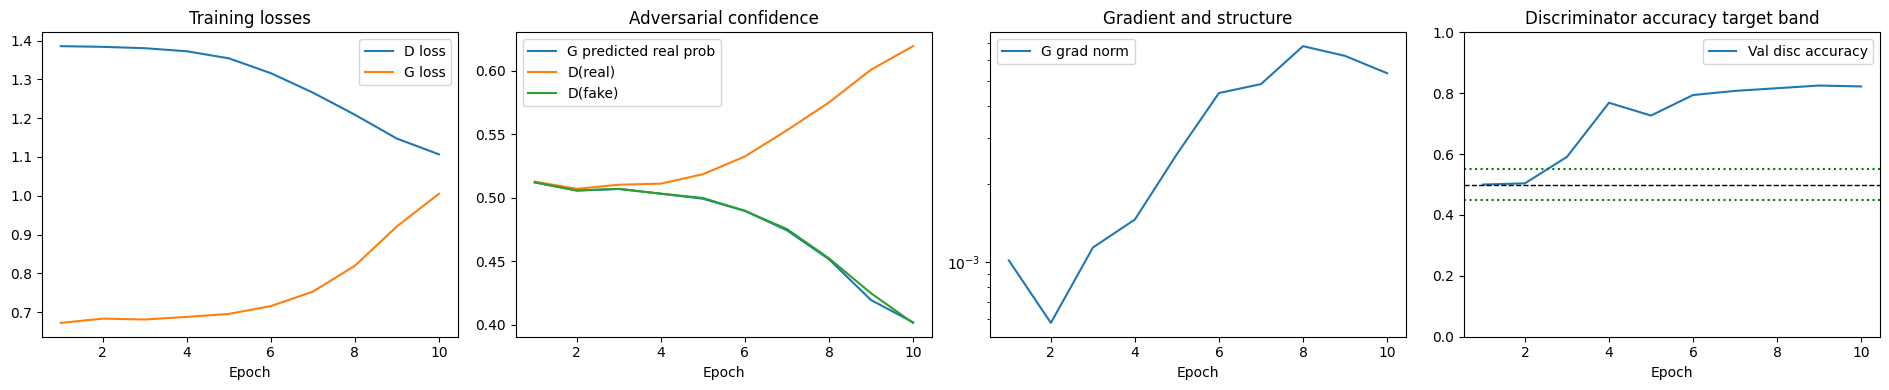

In [40]:
# Training curves
epochs_axis = np.arange(1, len(history['loss_D']) + 1)

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

axes[0].plot(epochs_axis, history['loss_D'], label='D loss')
axes[0].plot(epochs_axis, history['loss_G'], label='G loss')
axes[0].set_title('Training losses')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_axis, history['g_real_prob'], label='G predicted real prob')
if 'd_real_prob' in history and 'd_fake_prob' in history:
    axes[1].plot(epochs_axis, history['d_real_prob'], label='D(real)')
    axes[1].plot(epochs_axis, history['d_fake_prob'], label='D(fake)')
axes[1].set_title('Adversarial confidence')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs_axis, history['g_grad_norm'], label='G grad norm')
if 'g_n_soft_mean' in history:
    axes[2].plot(epochs_axis, history['g_n_soft_mean'], label='G n_soft mean')
axes[2].set_title('Gradient and structure')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].legend()

axes[3].plot(epochs_axis, history['val_disc_acc'], label='Val disc accuracy')
axes[3].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[3].axhline(0.55, color='green', linestyle=':')
axes[3].axhline(0.45, color='green', linestyle=':')
axes[3].set_ylim(0.0, 1.0)
axes[3].set_title('Discriminator accuracy target band')
axes[3].set_xlabel('Epoch')
axes[3].legend()

plt.tight_layout()
plt.show()

In [41]:
# Export calibrated simulator kwargs from the trained generator
EXPORT_DIR = Path('./calibrated_params')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def collect_policy_records(generator, discriminator, n_samples=2000, sample_batch=256):
    generator.eval()
    discriminator.eval()

    rows = []
    remaining = int(n_samples)
    with torch.no_grad():
        while remaining > 0:
            b = min(sample_batch, remaining)
            x_fake, _, recs = render_fake_batch(generator, b, anchor_params_bank_t, device, return_records=True)
            p_real = torch.sigmoid(discriminator(x_fake)).squeeze(1).detach().cpu().numpy()

            for rec, score in zip(recs, p_real):
                row = dict(rec)
                row['disc_real_prob'] = float(score)
                rows.append(row)

            remaining -= b

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError('No generator records were generated.')

    # Samples that most fool D are those with high predicted real probability.
    df = df.sort_values('disc_real_prob', ascending=False).reset_index(drop=True)
    return df

records_df = collect_policy_records(G, D, n_samples=3000, sample_batch=batch_size)

top_k = 200
top_df = records_df.head(top_k).copy()

numeric_cols = [
    c for c in records_df.columns
    if pd.api.types.is_numeric_dtype(records_df[c]) and not pd.api.types.is_bool_dtype(records_df[c])
]
quantiles = records_df[numeric_cols].quantile([0.05, 0.5, 0.95]).to_dict()

# Build compact summaries for later simulator sweeps.
summary = {
    'n_samples': int(len(records_df)),
    'top_k': int(top_k),
    'columns': list(records_df.columns),
    'quantiles': quantiles,
    'best_example': top_df.iloc[0].to_dict(),
}

all_csv = EXPORT_DIR / 'policy_records_all.csv'
top_csv = EXPORT_DIR / 'policy_records_top200.csv'
summary_json = EXPORT_DIR / 'policy_summary.json'
top_json = EXPORT_DIR / 'policy_top200.json'

records_df.to_csv(all_csv, index=False)
top_df.to_csv(top_csv, index=False)
top_df.to_json(top_json, orient='records', indent=2)
with summary_json.open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('Saved:')
print(' -', all_csv.resolve())
print(' -', top_csv.resolve())
print(' -', top_json.resolve())
print(' -', summary_json.resolve())

# Ready-to-use kwargs payloads for simulate_image(...)
sim_kwargs_top = top_df.drop(columns=['disc_real_prob']).to_dict(orient='records')
sim_kwargs_top_soliton = [kw for kw in sim_kwargs_top if int(kw.get('num_solitons', 0)) > 0]
print('Top kwargs available in variable: sim_kwargs_top (length =', len(sim_kwargs_top), ')')
print('Top kwargs with solitons in variable: sim_kwargs_top_soliton (length =', len(sim_kwargs_top_soliton), ')')
print('Top-200 num_solitons counts:', top_df['num_solitons'].value_counts(dropna=False).to_dict())

Saved:
 - C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\calibrated_params\policy_records_all.csv
 - C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\calibrated_params\policy_records_top200.csv
 - C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\calibrated_params\policy_top200.json
 - C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\calibrated_params\policy_summary.json
Top kwargs available in variable: sim_kwargs_top (length = 200 )
Top kwargs with solitons in variable: sim_kwargs_top_soliton (length = 106 )
Top-200 num_solitons counts: {0: 94, 1: 86, 2: 20}


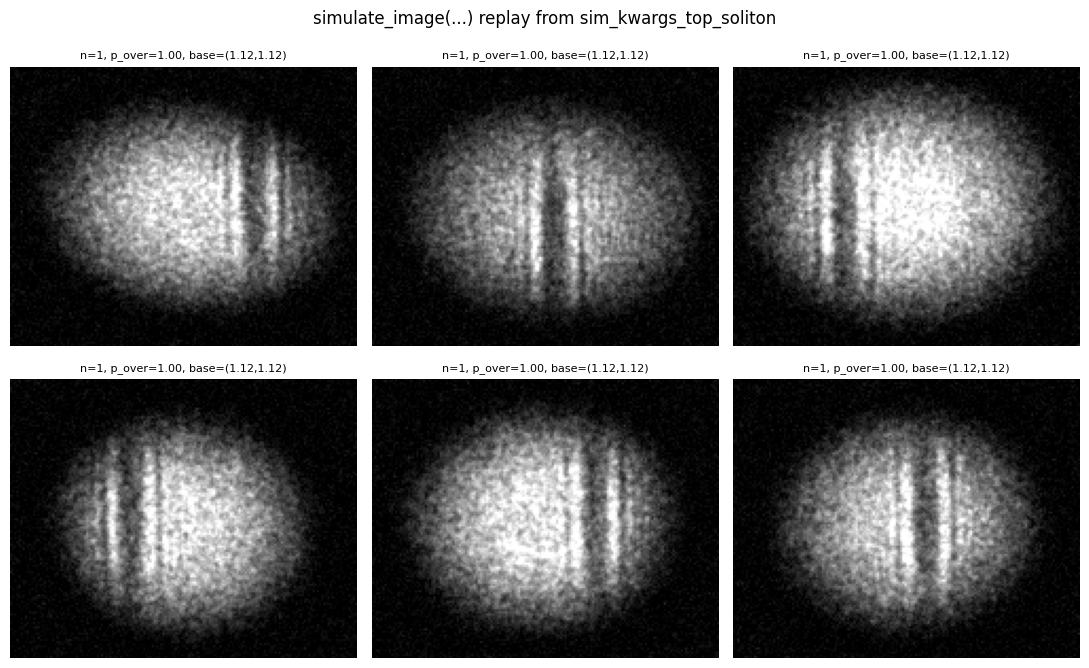

Replayed 6 images via simulate_image(anchor_for_replay, **kwargs) from sim_kwargs_top_soliton
num_solitons values used: [1, 1, 1, 1, 1, 1]


In [42]:
# Validation: recreate images directly from exported kwargs using torch simulator
if len(sim_kwargs_top) == 0:
    raise RuntimeError('sim_kwargs_top is empty. Run export cell first.')

replay_source = sim_kwargs_top_soliton if len(sim_kwargs_top_soliton) > 0 else sim_kwargs_top
replay_source_name = 'sim_kwargs_top_soliton' if len(sim_kwargs_top_soliton) > 0 else 'sim_kwargs_top'
n_check = min(6, len(replay_source))
anchor_for_replay = anchor_params_bank[0]

replayed = []
for i in range(n_check):
    kwargs = dict(replay_source[i])
    img, used_cfg = simulate_image(anchor_for_replay, rng=np.random.default_rng(SEED + i), **kwargs)
    replayed.append((img, used_cfg))

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i >= n_check:
        ax.axis('off')
        continue

    img, cfg = replayed[i]
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(
        f"n={int(cfg['num_solitons'])}, p_over={cfg['overexposure_prob']:.2f}, base=({cfg['base_gain_low']:.2f},{cfg['base_gain_high']:.2f})",
        fontsize=8,
    )
    ax.axis('off')

plt.suptitle(f'simulate_image(...) replay from {replay_source_name}', y=0.98)
plt.tight_layout()
plt.show()

print('Replayed', n_check, 'images via simulate_image(anchor_for_replay, **kwargs) from', replay_source_name)
print('num_solitons values used:', [int(r[1]['num_solitons']) for r in replayed])

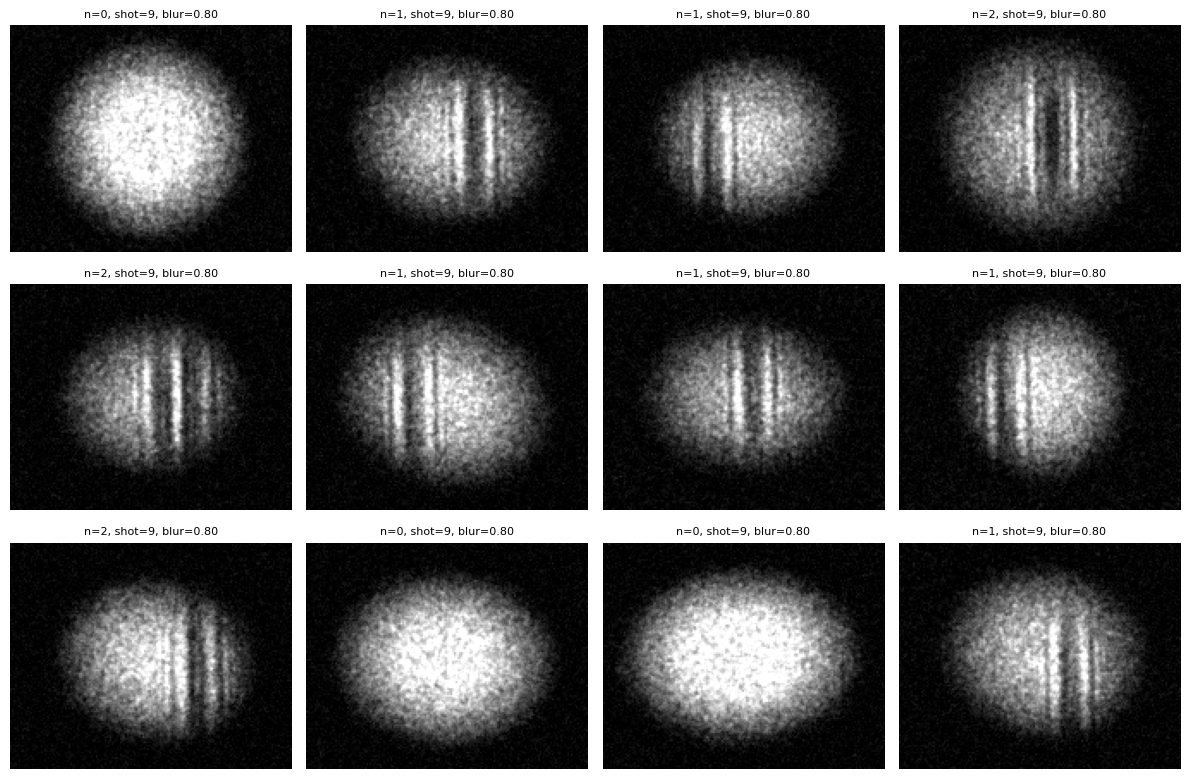

In [43]:
# Visual sanity check: generated samples after training
G.eval()
with torch.no_grad():
    x_fake, _, records = render_fake_batch(G, 12, anchor_params_bank_t, device, return_records=True)

fake_np = x_fake.squeeze(1).cpu().numpy()

fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(fake_np[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(
        f"n={records[i]['num_solitons']}, shot={records[i]['shot_photons']}, blur={records[i]['gaussian_sigma']:.2f}",
        fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [44]:
# Diagnostic: distribution of generated soliton controls
G.eval()
with torch.no_grad():
    _, params_diag, records_diag = render_fake_batch(G, 1024, anchor_params_bank_t, device, return_records=True)

num_diag = np.array([r['num_solitons'] for r in records_diag], dtype=int)
add_diag = np.array([int(r['add_soliton']) for r in records_diag], dtype=int)

print('num_solitons counts:', {k: int((num_diag == k).sum()) for k in [0, 1, 2]})
print('add_soliton (derived from n>0) rate:', float(add_diag.mean()))
print('n_solitons_soft mean/std:', float(params_diag['n_solitons_soft'].mean().item()), float(params_diag['n_solitons_soft'].std().item()))

num_solitons counts: {0: 207, 1: 640, 2: 177}
add_soliton (derived from n>0) rate: 0.7978515625
n_solitons_soft mean/std: 0.970703125 0.6119701266288757


In [45]:
# Quick gradient sanity check (single mini-step, no full training)
D_probe = Discriminator().to(device)
G_probe = ParamGenerator(z_dim=64, n_out=N_GENERATOR_OUTPUTS).to(device)

bce_probe = nn.BCEWithLogitsLoss()
opt_probe = torch.optim.Adam(G_probe.parameters(), lr=2e-4, betas=(0.5, 0.999))

x_fake_probe, _, _ = render_fake_batch(G_probe, 12, anchor_params_bank_t, device, return_records=False)
fake_logits_probe = D_probe(x_fake_probe)
loss_probe = bce_probe(fake_logits_probe, torch.ones_like(fake_logits_probe))

opt_probe.zero_grad()
loss_probe.backward()

probe_grad_sq = 0.0
for p in G_probe.parameters():
    if p.grad is not None:
        probe_grad_sq += float(p.grad.detach().pow(2).sum().item())
probe_grad_norm = probe_grad_sq ** 0.5

print(f"probe_loss={loss_probe.item():.4f}, probe_G_grad_norm={probe_grad_norm:.3e}")

probe_loss=0.7430, probe_G_grad_norm=6.218e-04


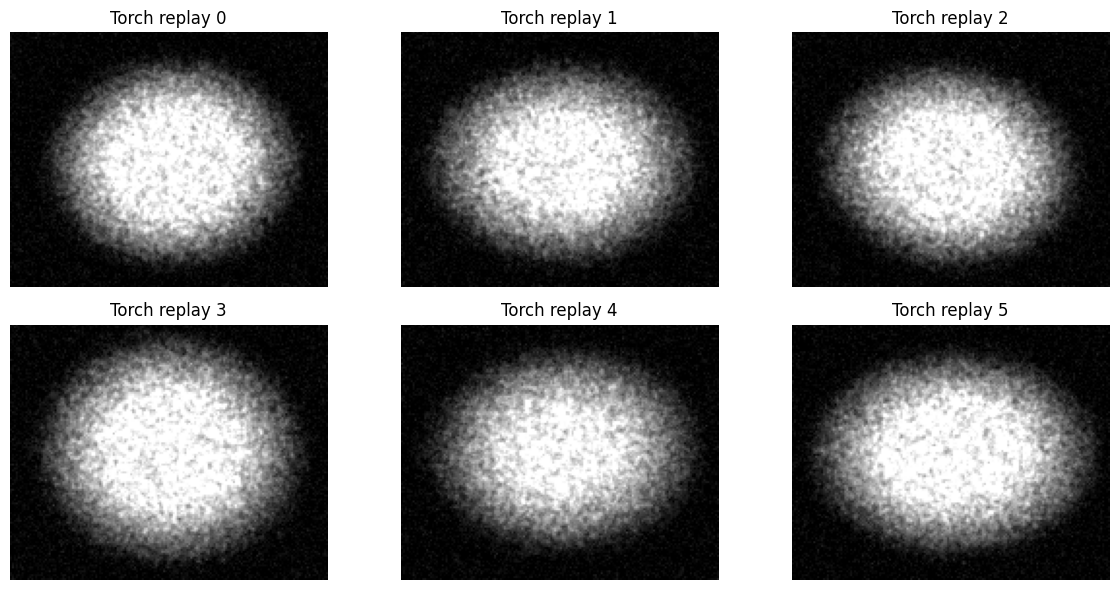

In [46]:
# Torch renderer replay check for the same exported configs
if len(sim_kwargs_top) == 0:
    raise RuntimeError('sim_kwargs_top is empty. Run export cell first.')

anchor_for_compare = anchor_params_bank[0]
n_show = min(6, len(sim_kwargs_top))
imgs = []
for i in range(n_show):
    img_i, _ = simulate_image(anchor_for_compare, rng=np.random.default_rng(SEED + 1000 + i), **sim_kwargs_top[i])
    imgs.append(img_i)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i >= n_show:
        ax.axis('off')
        continue
    ax.imshow(imgs[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Torch replay {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()